In [51]:
#Boilerplate
from pathlib import Path
#General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Analysis module
import evaluation_tools.inc_learn_tests as st

In [20]:

#Here's what we're testing
results = {'logistic': pd.DataFrame, 'svm':pd.DataFrame, 'xgboost':pd.DataFrame}

In [ ]:
def read_and_append(file:Path, accumulation_list:list):
    df = pd.read_csv(file, index_col=0)
    acc = df.loc['accuracy'].iloc[0]
    accumulation_list.append(acc)
    return accumulation_list

def inc_base_reader(num_batches:int, result_dict:dict, num_tests:int):
    for clf, _ in result_dict.items():
        results_dir = Path.cwd() / 'results' / 'big_init_chunk' / f"{clf}"
        inc_test_results = []
        inc_train_results = []
        baseline_results = []
        for i in range(num_batches):
            for j in range(num_tests):
                inc_test_results = read_and_append(results_dir / f"{clf}_inc_test{j}_batch{i}_test_accuracy.csv", inc_test_results)
                inc_train_results = read_and_append(results_dir / f"{clf}_inc_test{j}_batch{i}_train_accuracy.csv", inc_train_results)
                baseline_results = read_and_append(results_dir / f"{clf}_base_test{j}_batch{i}_test_accuracy.csv", baseline_results)
            
        inc_test_df = pd.DataFrame(inc_test_results, columns=[f"{clf}_inc_test_accuracy"])
        inc_train_df = pd.DataFrame(inc_train_results, columns=[f"{clf}_inc_train_accuracy"])
        base_df = pd.DataFrame(baseline_results, columns=[f"{clf}_baseline_test_accuracy"])
        results = pd.concat([inc_test_df, inc_train_df, base_df], axis=1)
        
        result_dict[clf] = results
    return result_dict



In [22]:
results = inc_base_reader(5, results, 10)

In [23]:
# results['logistic']

In [24]:
full_results = pd.concat(results, axis=1).droplevel(level=0, axis=1)

In [47]:
#Setup the variables
# cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=0)
basics = st.TestVariables(results=full_results, num_test=10)
rope_interval = [-0.01, 0.01]
means_dict = {}
vars_dict = {}
for col in basics.model_scores.transpose().columns:
    m, v = st.get_mean_var(basics.model_scores.transpose()[col].to_numpy(), 5, 10)
    means_dict[col] = m
    vars_dict[col] = v

mean_model_scores = pd.DataFrame(means_dict)
var_model_scores = pd.DataFrame(vars_dict)

### Proof of Point

### Pairwise Frequentist

In [28]:
pairwise_comp_df = st.pairwise_freq(model_scores=basics.model_scores, num_tests=10, num_batches=basics.num_batch, pairwise_comp_df=None)

In [29]:
# pairwise_comp_df.sort_values(['p_val', 't_stat'])

### Pairwise Bayesian

In [30]:
pairwise_comp_df = st.pairwise_bayesian(model_scores=basics.model_scores, rope_interval=rope_interval, num_tests=10, num_batches=basics.num_batch, h=1, pairwise_comp_df=pairwise_comp_df)

In [52]:
import numpy as np

In [55]:
mean_model_scores

,logistic_inc_test_accuracy,logistic_inc_train_accuracy,logistic_baseline_test_accuracy,svm_inc_test_accuracy,svm_inc_train_accuracy,svm_baseline_test_accuracy,xgboost_inc_test_accuracy,xgboost_inc_train_accuracy,xgboost_baseline_test_accuracy
0,0.830386,0.874310,0.760678,0.813221,0.844690,0.772472,0.762395,0.798665,0.746806
1,0.836240,0.873745,0.785853,0.806827,0.842718,0.756944,0.779542,0.813000,0.754347
2,0.840026,0.880162,0.781029,0.786977,0.826836,0.745158,0.780629,0.819963,0.755419
3,0.829350,0.876107,0.754798,0.811093,0.848614,0.768185,0.783297,0.818370,0.756495
4,0.834649,0.877783,0.776198,0.803610,0.841724,0.740308,0.782222,0.816237,0.756495


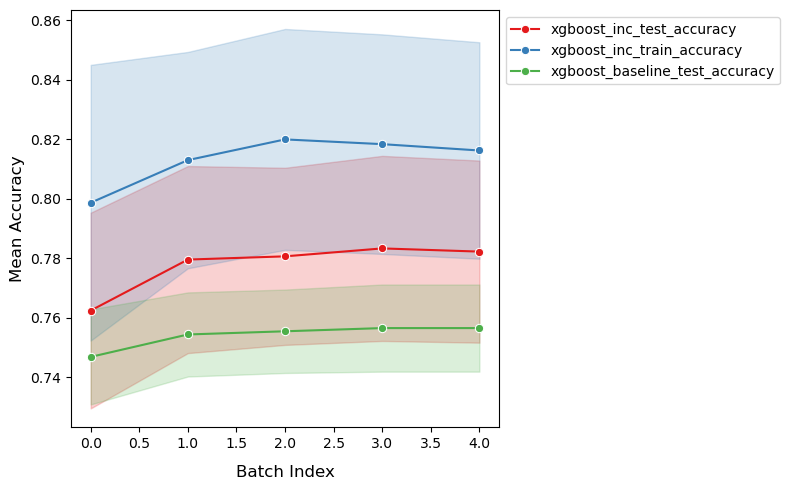

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plot_df = mean_model_scores.iloc[:, 6:]

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Set1", n_colors=len(plot_df.columns))

for i, col in enumerate(plot_df.columns):
    x = plot_df.index
    mean = plot_df[col]
    std = np.sqrt(var_model_scores[col])  # Standard deviation

    # Draw main line
    sns.lineplot(
        x=x,
        y=mean,
        label=col,
        color=colors[i],
        marker="o",
        ax=ax,
    )
    # Add shaded error band (mean ± std)
    ax.fill_between(x, mean - std, mean + std, color=colors[i], alpha=0.2)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("Batch Index", size=12, labelpad=10)
ax.set_ylabel("Mean Accuracy", size=12)

plt.tight_layout()
plt.show()

### Interpretation Notes
 - Null Hypothesis is that the two models have the same loss. 
 - Loss Differential (d)=Model 1 Error−Model 2 Error. So a negitive t_stat means that model 2 has higher loss than model 1. 

In [ ]:
pairwise_comp_df.sort_values(['model_1', 'model_2'], ascending=True).dropna().iloc[[6, 7, ]]

,model_1,model_2,t_stat,p_val,worse_prob,better_prob,rope_prob
17,logistic_baseline_test_accuracy,svm_baseline_test_accuracy,-0.948,1.000,0.037,0.365,0.598
15,logistic_baseline_test_accuracy,svm_inc_test_accuracy,1.495,1.000,0.624,0.023,0.353
16,logistic_baseline_test_accuracy,svm_inc_train_accuracy,2.402,1.000,0.899,0.010,0.090
20,logistic_baseline_test_accuracy,xgboost_baseline_test_accuracy,-1.291,1.000,0.016,0.364,0.620
18,logistic_baseline_test_accuracy,xgboost_inc_test_accuracy,0.318,1.000,0.203,0.092,0.705
19,logistic_baseline_test_accuracy,xgboost_inc_train_accuracy,1.481,1.000,0.711,0.032,0.257
1,logistic_inc_test_accuracy,logistic_baseline_test_accuracy,-3.435,0.334,0.002,0.946,0.052
0,logistic_inc_test_accuracy,logistic_inc_train_accuracy,1.087,1.000,0.588,0.055,0.357
4,logistic_inc_test_accuracy,svm_baseline_test_accuracy,-3.635,0.270,0.002,0.971,0.027
2,logistic_inc_test_accuracy,svm_inc_test_accuracy,-2.101,1.000,0.005,0.528,0.468


## Generalizability 

In [ ]:
mean, var = st.get_mean_var(basics.model_scores.transpose()['logistic_inc_test_accuracy'].to_numpy(), 5, 10)

In [34]:
mean

array([0.83038552, 0.83623955, 0.84002606, 0.82935041, 0.8346494 ])

In [35]:
var

array([0.00310612, 0.00175996, 0.00200021, 0.00306488, 0.00236769])

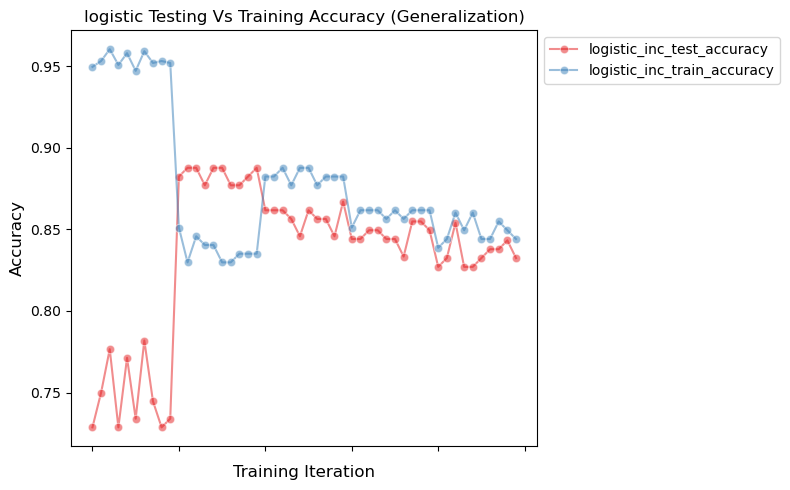

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_16087/1311454092.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


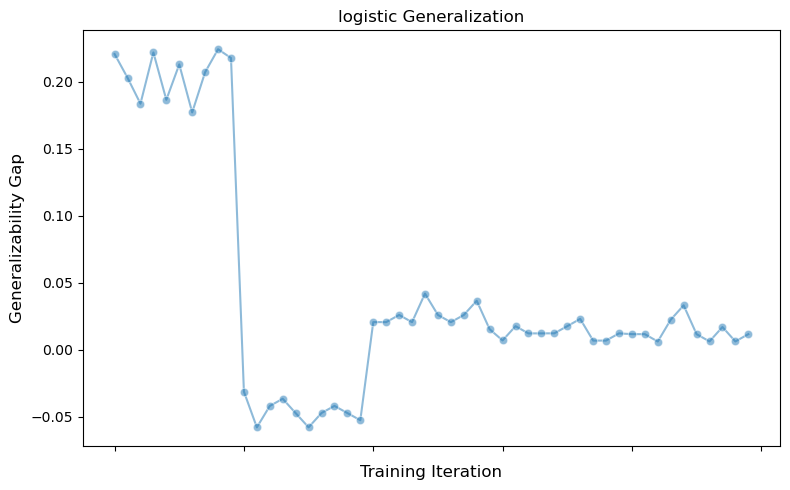

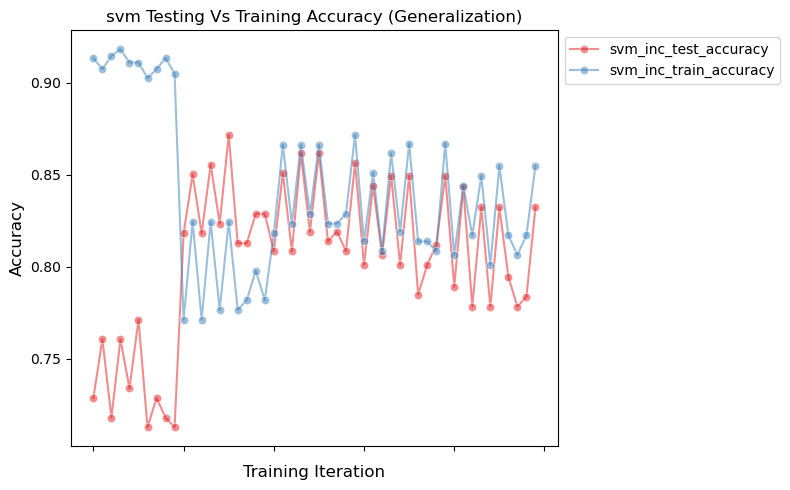

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_16087/1311454092.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


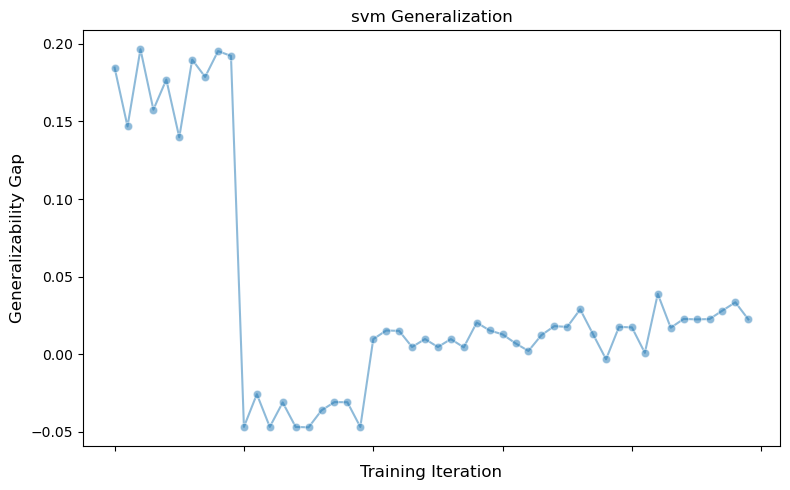

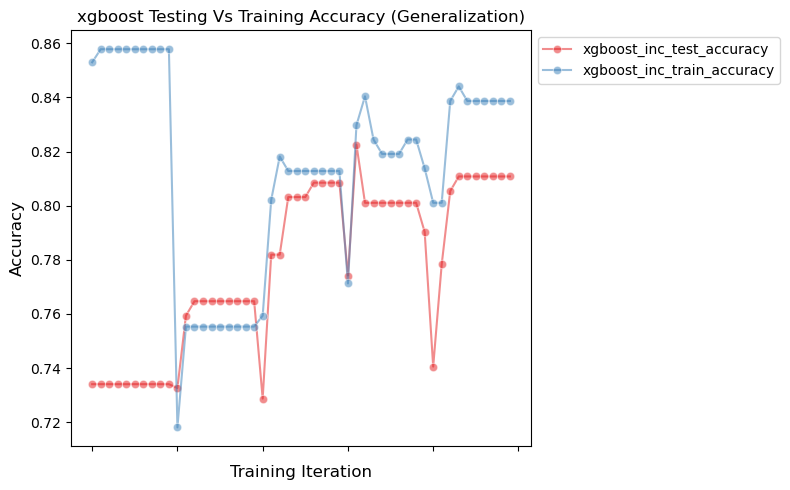

/var/folders/tw/xg2s15ms5k9g_tftbp9yblmm0000gn/T/ipykernel_16087/1311454092.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


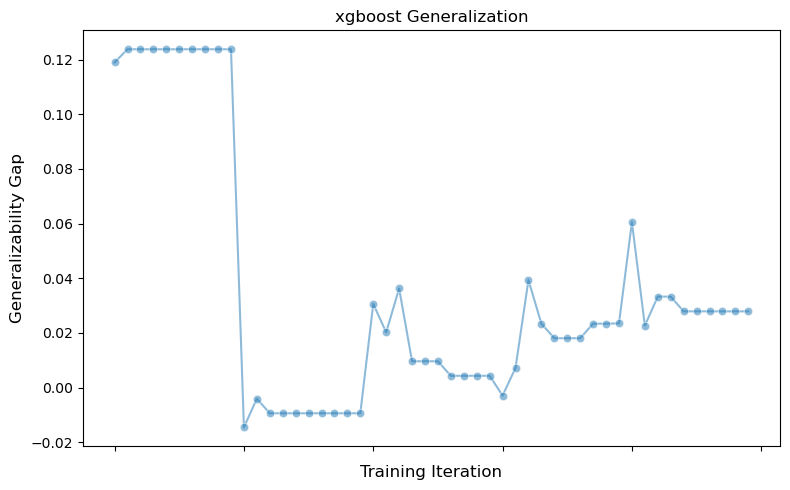

In [ ]:
def overfitting_plt(model:str):
    compare = basics.model_scores.transpose()[[f"{model}_inc_test_accuracy", f"{model}_inc_train_accuracy"]]
    gen =compare[f"{model}_inc_train_accuracy"] - compare[f"{model}_inc_test_accuracy"]
# plot accuracy
    fig, ax = plt.subplots(figsize=(8, 5))  # slightly wider figure gives room
    sns.lineplot(
    data=compare,
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

# Move legend outside the plot area to the right
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    ax.set_xlabel("Training Iteration", size=12, labelpad=10)
    ax.set_ylabel("Accuracy", size=12)
    ax.tick_params(bottom=True, labelbottom=False)
    ax.set_title(f"{model} Testing Vs Training Accuracy (Generalization)")

    plt.tight_layout()  # prevents legend text from getting clipped
    plt.show()

    # plot generalizability
    fig, ax = plt.subplots(figsize=(8, 5))  # slightly wider figure gives room
    sns.lineplot(
    data=gen,
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

# Move legend outside the plot area to the right
    # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    ax.set_xlabel("Training Iteration", size=12, labelpad=10)
    ax.set_ylabel("Generalizability Gap", size=12)
    ax.tick_params(bottom=True, labelbottom=False)
    ax.set_title(f"{model} Generalization")

    plt.tight_layout()  # prevents legend text from getting clipped
    plt.show()

for clf in results.keys():
    overfitting_plt(clf)